# Adjoint sensitivities (spatial Kuramoto)

This notebook runs a small spatial-coupling Kuramoto simulation and visualizes gradients of:

- final global order parameter $R(T)$ w.r.t. coupling weights $K$ and natural frequencies $\omega$
- time-averaged order parameter (mean of $R(t)$ over saved times) w.r.t. $K$ and $\omega$

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    build_simulation,
)
from kuramoto.analysis import get_R
from kuramoto.adjoint import grads_final_R, grads_mean_R
from kuramoto.plotting import plot_2d

SEED = 42
grid_shape = (16, 16)

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        mode="spatial",
        kernel="gaussian",
        base_strength=1.0,
        radius=5.0,
        kernel_params={"sigma": 2.0},
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=SEED,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

t0, t1, dt = 0.0, 5.0, 0.05

# Forward solve (for visualization + order statistics)
results = sim.run((t0, t1), dt)

# Objective time grid used by the adjoint functions
ts = jnp.arange(t0 + dt, t1 + dt / 2, dt)
ts = ts[ts <= t1]

R_series, psi_series = get_R(results["theta"])
R_final = float(R_series[-1])
R_mean = float(np.mean(R_series))

print(f"R_final = {R_final:.6f}")
print(f"R_mean  = {R_mean:.6f}")

R_final = 0.999734
R_mean  = 0.928728


In [ ]:
# Gradients of final R and mean R.
# Note: grads_final_R / grads_mean_R return a KuramotoParams pytree,
# so the gradients come back as (.K, .omega).

g_final = grads_final_R(sim.params, sim.theta0, t0, t1, dt, ts=ts)
g_mean  = grads_mean_R(sim.params, sim.theta0, t0, t1, dt, ts=ts)

dK_final = np.asarray(g_final.K)
dK_mean  = np.asarray(g_mean.K)

domega_final = np.asarray(g_final.omega)
domega_mean  = np.asarray(g_mean.omega)

print("Shapes:")
print("  dK_final:", dK_final.shape)
print("  domega_final:", domega_final.shape)

# Useful scales for visualization
abs_dK_final = np.abs(dK_final)
abs_dK_mean  = np.abs(dK_mean)
eps = 1e-12
log_abs_dK_final = np.log10(abs_dK_final + eps)
log_abs_dK_mean  = np.log10(abs_dK_mean + eps)

print("Max |dR_final/dK|:", float(np.max(abs_dK_final)))
print("Max |dR_mean/dK|: ", float(np.max(abs_dK_mean)))

Shapes:
  dK_final: (256, 256)
  domega_final: (256,)
Max |dR_final/dK|: 1.3042093996773474e-05
Max |dR_mean/dK|:  0.009089905768632889


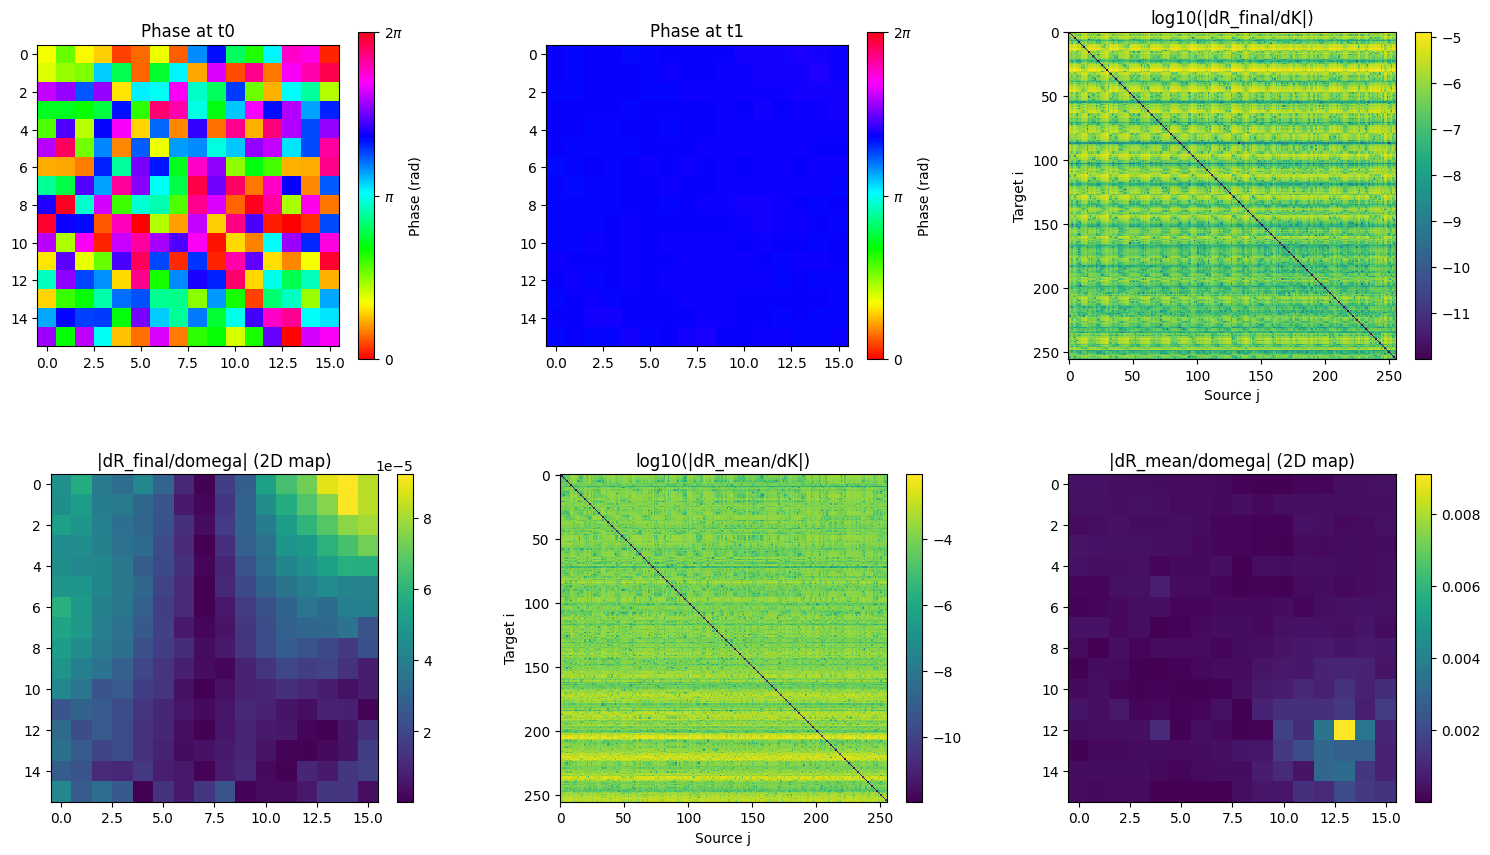

Done.


In [ ]:
# Plot phase maps and gradient diagnostics
theta0_2d = sim.grid.unflatten(results["theta"][0])
theta1_2d = sim.grid.unflatten(results["theta"][-1])

domega_final_2d = sim.grid.unflatten(domega_final)
domega_mean_2d  = sim.grid.unflatten(domega_mean)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(wspace=0.35, hspace=0.35)

# Phase at start/end
plot_2d(theta0_2d, variable="phase", ax=axes[0, 0], title="Phase at t0")
plot_2d(theta1_2d, variable="phase", ax=axes[0, 1], title="Phase at t1")

# dR/dK heatmaps (log scale)
im0 = axes[0, 2].imshow(log_abs_dK_final, aspect="equal", interpolation="nearest")
axes[0, 2].set_title("log10(|dR_final/dK|)")
axes[0, 2].set_xlabel("Source j")
axes[0, 2].set_ylabel("Target i")
fig.colorbar(im0, ax=axes[0, 2], fraction=0.046)

# dR/domega maps
im1 = axes[1, 0].imshow(np.abs(domega_final_2d), cmap="viridis", aspect="equal", interpolation="nearest")
axes[1, 0].set_title("|dR_final/domega| (2D map)")
fig.colorbar(im1, ax=axes[1, 0], fraction=0.046)

# Mean gradients
im2 = axes[1, 1].imshow(log_abs_dK_mean, aspect="equal", interpolation="nearest")
axes[1, 1].set_title("log10(|dR_mean/dK|)")
axes[1, 1].set_xlabel("Source j")
axes[1, 1].set_ylabel("Target i")
fig.colorbar(im2, ax=axes[1, 1], fraction=0.046)

im3 = axes[1, 2].imshow(np.abs(domega_mean_2d), cmap="viridis", aspect="equal", interpolation="nearest")
axes[1, 2].set_title("|dR_mean/domega| (2D map)")
fig.colorbar(im3, ax=axes[1, 2], fraction=0.046)

plt.show()